# Detección de Células AOSLO mediante Bounding Boxes
**Enfoque:** Detección de objetos con CNN (CenterNet anchor-free)  
**Framework:** PyTorch + OpenCV + Matplotlib  
**Dataset:** Dubis — 264 imágenes AOSLO 256×256

## Celda 1 — Instalación y clonado del repositorio

In [34]:
import os, subprocess, sys

REPO_URL  = 'https://github.com/nicolaycz/AOSLO-Cell-Density-Estimation.git'
REPO_DIR  = 'AOSLO-Cell-Density-Estimation'
DATA_DIR  = os.path.join(REPO_DIR, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'Training+Density')
VAL_DIR   = os.path.join(DATA_DIR, 'Validation+Density')

if not os.path.isdir(REPO_DIR):
    print('Clonando repositorio...')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL], check=True)
else:
    print('Repositorio ya presente:', REPO_DIR)

print('Contenido de data/:', os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else 'NO EXISTE')
print('Train dir existe:', os.path.isdir(TRAIN_DIR))
print('Val   dir existe:', os.path.isdir(VAL_DIR))

Repositorio ya presente: AOSLO-Cell-Density-Estimation
Contenido de data/: ['README.md', 'Training+Density', 'Validation+Density']
Train dir existe: True
Val   dir existe: True


## Celda 2 — Imports principales

In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy.ndimage import label, maximum_filter, generate_binary_structure
from glob import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Celda 3 — Parámetros de bounding box (PARAMÉTRICO)

In [36]:
# Tamaño promedio de una célula en píxeles (ajustable)
CELL_W = 12   # ancho del bbox
CELL_H = 12   # alto del bbox
IMG_SIZE = 256 # dimensión de las imágenes AOSLO

print(f'Bounding box paramétrico: {CELL_W}x{CELL_H} px')

Bounding box paramétrico: 12x12 px


## Celda 4 — Funciones: extraer centroides y construir bboxes

In [37]:
def extract_centroids_from_density(density_path, threshold_ratio=0.15):
    """Extrae coordenadas (x, y) de centroides desde un mapa de densidad
    usando detección de máximos locales."""
    density = np.array(Image.open(density_path)).astype(np.float32)
    if density.ndim == 3:
        density = density[:, :, 0]

    # Umbral adaptativo basado en el máximo
    if density.max() == 0:
        return np.array([]).reshape(0, 2)

    thresh = density.max() * threshold_ratio
    # Máximos locales con neighborhood 3x3
    struct = generate_binary_structure(2, 2)
    local_max = maximum_filter(density, footprint=struct) == density
    detected = (density > thresh) & local_max

    # Etiquetar componentes y obtener centroides
    labeled, n_feat = label(detected)
    centroids = []
    for i in range(1, n_feat + 1):
        ys, xs = np.where(labeled == i)
        cy, cx = ys.mean(), xs.mean()
        centroids.append([cx, cy])  # (x, y)

    return np.array(centroids) if centroids else np.array([]).reshape(0, 2)


def centroids_to_bboxes(centroids, img_h=IMG_SIZE, img_w=IMG_SIZE,
                        cell_w=CELL_W, cell_h=CELL_H):
    """Convierte centroides (x, y) en bboxes [x_min, y_min, x_max, y_max]
    con gestión de bordes (clamp a límites de imagen)."""
    if len(centroids) == 0:
        return np.array([]).reshape(0, 4)

    hw, hh = cell_w / 2.0, cell_h / 2.0
    bboxes = []
    for cx, cy in centroids:
        x_min = max(0, cx - hw)
        y_min = max(0, cy - hh)
        x_max = min(img_w - 1, cx + hw)
        y_max = min(img_h - 1, cy + hh)
        bboxes.append([x_min, y_min, x_max, y_max])
    return np.array(bboxes, dtype=np.float32)


def load_image_and_bboxes(img_path, density_path):
    """Carga imagen + extrae bboxes desde density map."""
    img = np.array(Image.open(img_path).convert('RGB'))
    centroids = extract_centroids_from_density(density_path)
    bboxes = centroids_to_bboxes(centroids, img.shape[0], img.shape[1])
    return img, bboxes, centroids

print('Funciones de extracción de centroides y bboxes definidas ✓')

Funciones de extracción de centroides y bboxes definidas ✓


## Celda 5 — Listar pares imagen/densidad

In [38]:
def list_image_density_pairs(directory):
    """Retorna lista de tuplas (img_path, density_path) ordenadas."""
    img_files = sorted(glob(os.path.join(directory, '*.tif')))
    pairs = []
    for f in img_files:
        basename = os.path.basename(f)
        if 'Density' not in basename:
            base = os.path.splitext(f)[0]
            density_f = base + 'Density.tif'
            if not os.path.exists(density_f):
                density_f = base + '_Density.tif'
            if os.path.exists(density_f):
                pairs.append((f, density_f))
    return pairs

train_pairs = list_image_density_pairs(TRAIN_DIR)
val_pairs   = list_image_density_pairs(VAL_DIR)
print(f'Pares train: {len(train_pairs)}, val: {len(val_pairs)}')


Pares train: 184, val: 80


## Celda 6 — Visualización de ejemplo con bounding boxes

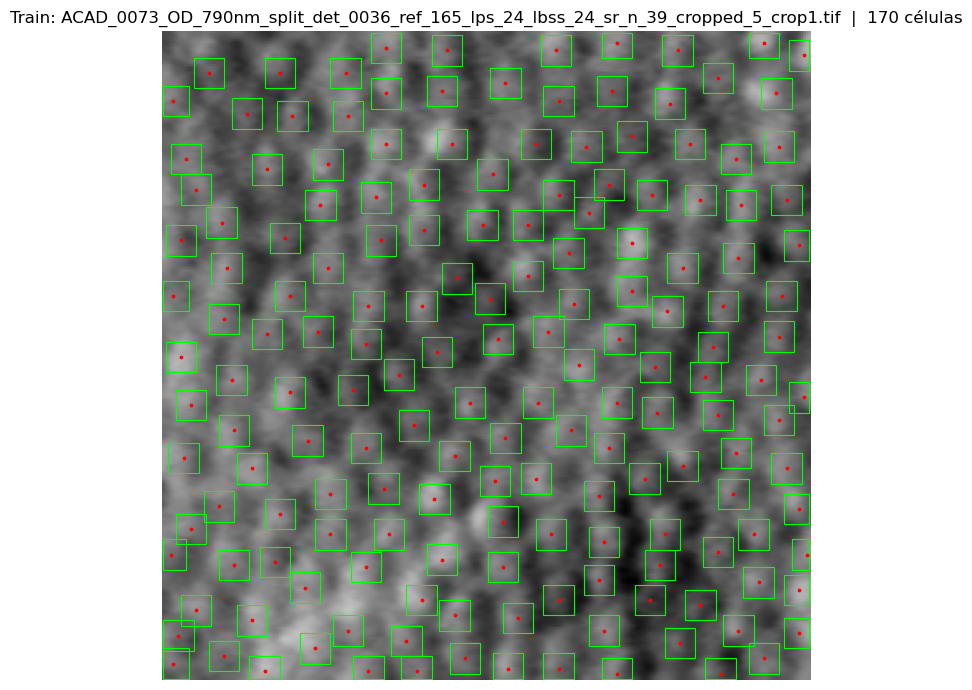

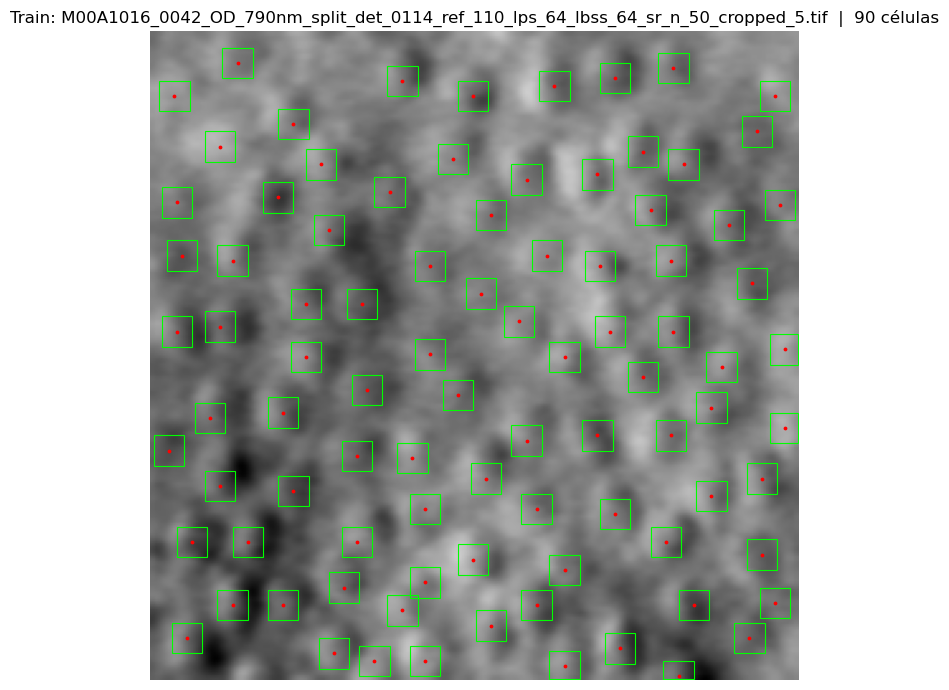

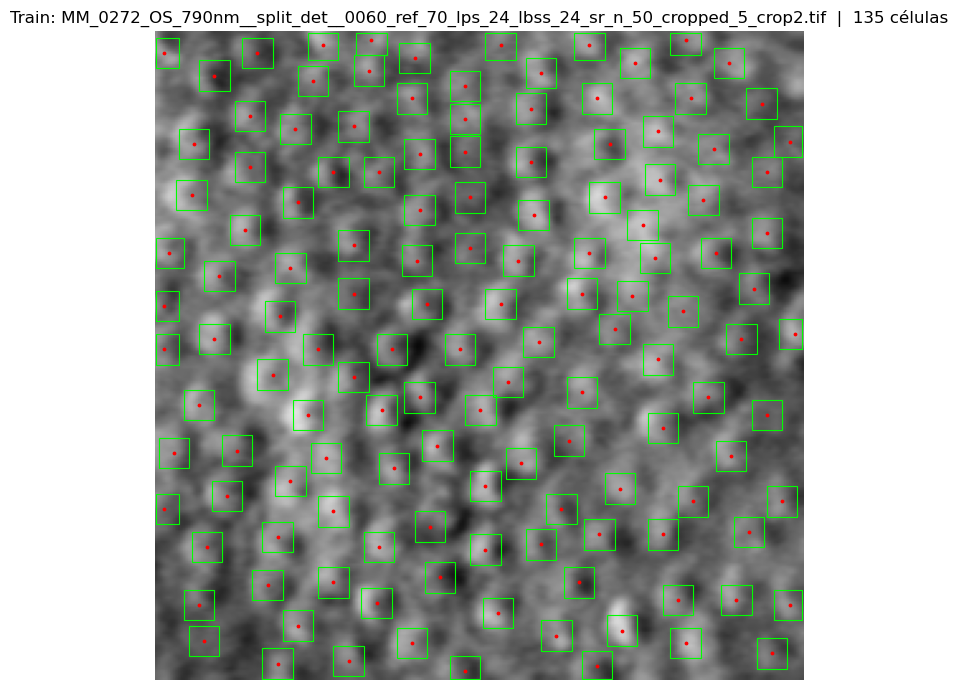

In [39]:
def visualize_bboxes(img, bboxes, centroids=None, title='', max_show=None):
    """Muestra imagen con bboxes superpuestos."""
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(img)
    for i, bb in enumerate(bboxes):
        if max_show and i >= max_show:
            break
        rect = patches.Rectangle(
            (bb[0], bb[1]), bb[2] - bb[0], bb[3] - bb[1],
            linewidth=0.8, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    if centroids is not None and len(centroids) > 0:
        show = centroids if max_show is None else centroids[:max_show]
        ax.scatter(show[:, 0], show[:, 1], c='red', s=3, zorder=5)
    ax.set_title(f'{title}  |  {len(bboxes)} células')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Mostrar 3 ejemplos de entrenamiento
if len(train_pairs) == 0:
    print("ERROR: train_pairs está vacío. Re-ejecuta la celda 5.")
else:
    for idx in [0, len(train_pairs)//2, len(train_pairs)-1]:
        img, bboxes, cents = load_image_and_bboxes(*train_pairs[idx])
        name = os.path.basename(train_pairs[idx][0])
        visualize_bboxes(img, bboxes, cents, title=f'Train: {name}')


## Celda 7 — Formato de anotaciones para detección

In [40]:
# Cada imagen se anota como dict:
# { 'boxes': Tensor [N,4] en formato xyxy, 'labels': Tensor [N] (clase 1) }

def build_target(bboxes):
    """Construye target dict compatible con detección de objetos."""
    if len(bboxes) == 0:
        return {'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,), dtype=torch.int64)}
    return {
        'boxes':  torch.tensor(bboxes, dtype=torch.float32),
        'labels': torch.ones(len(bboxes), dtype=torch.int64)  # clase 1 = célula
    }

## Celda 8 — Dataset de PyTorch para detección

In [41]:
class AOSLODetectionDataset(Dataset):
    """Dataset que retorna (imagen_tensor, target_dict) para detección."""

    def __init__(self, pairs, img_size=IMG_SIZE, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, density_path = self.pairs[idx]
        img = np.array(Image.open(img_path).convert('RGB')).astype(np.float32)
        centroids = extract_centroids_from_density(density_path)
        bboxes = centroids_to_bboxes(centroids, img.shape[0], img.shape[1])

        # Augmentación simple: flip horizontal
        if self.augment and np.random.rand() > 0.5:
            img = img[:, ::-1, :].copy()
            if len(bboxes) > 0:
                w = img.shape[1]
                x_min_new = w - 1 - bboxes[:, 2]
                x_max_new = w - 1 - bboxes[:, 0]
                bboxes[:, 0] = x_min_new
                bboxes[:, 2] = x_max_new

        # Normalizar a [0,1] y cambiar a CHW
        img_t = torch.from_numpy(img / 255.0).permute(2, 0, 1).float()
        target = build_target(bboxes)
        return img_t, target


def collate_fn(batch):
    """Collate custom: las listas de targets tienen tamaño variable."""
    imgs = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return imgs, targets

train_ds = AOSLODetectionDataset(train_pairs, augment=True)
val_ds   = AOSLODetectionDataset(val_pairs, augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

# Verificar un batch
imgs, targets = next(iter(train_loader))
print(f'Batch imgs: {imgs.shape}')
print(f'Targets[0] boxes: {targets[0]["boxes"].shape}')
print(f'Dataset listo ✓  Train={len(train_ds)}, Val={len(val_ds)}')

Batch imgs: torch.Size([4, 3, 256, 256])
Targets[0] boxes: torch.Size([68, 4])
Dataset listo ✓  Train=184, Val=80


## Celda 9 — Modelo CNN: Detector anchor-free para objetos

In [42]:
# Arquitectura: backbone ligero → FPN simplificado → 2 heads:
#   1) Heatmap head (probabilidad de centro de célula por píxel)
#   2) Size head (regresión de w, h del bbox por píxel)
# Inspirado en CenterNet (Zhou et al. 2019) adaptado a células.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os, time

# Si se ejecuta standalone, importar constantes de parte 1
try:
    _ = DEVICE
except NameError:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    IMG_SIZE = 256
    CELL_W = 12
    CELL_H = 12


class ConvBlock(nn.Module):
    """Conv2d + BatchNorm + ReLU."""
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.block(x)


class CellDetectorCNN(nn.Module):
    """Detector anchor-free tipo CenterNet para células AOSLO.
    Output stride = 4 → heatmap de 64x64 para imagen 256x256."""

    def __init__(self):
        super().__init__()
        # --- Encoder (backbone ligero) ---
        self.enc1 = nn.Sequential(ConvBlock(3, 32), ConvBlock(32, 32))
        self.enc2 = nn.Sequential(ConvBlock(32, 64), ConvBlock(64, 64))
        self.enc3 = nn.Sequential(ConvBlock(64, 128), ConvBlock(128, 128))
        self.enc4 = nn.Sequential(ConvBlock(128, 256), ConvBlock(256, 256))
        self.pool = nn.MaxPool2d(2, 2)

        # --- Decoder (upsampling con skip connections) ---
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = nn.Sequential(ConvBlock(256, 128), ConvBlock(128, 128))
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(ConvBlock(128, 64), ConvBlock(64, 64))
        # output stride = 4 (no upsamplamos más)

        # --- Detection heads ---
        self.heatmap_head = nn.Sequential(
            ConvBlock(64, 32), nn.Conv2d(32, 1, 1), nn.Sigmoid())
        self.size_head = nn.Sequential(
            ConvBlock(64, 32), nn.Conv2d(32, 2, 1), nn.ReLU())

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                  # 256x256
        e2 = self.enc2(self.pool(e1))      # 128x128
        e3 = self.enc3(self.pool(e2))      # 64x64
        e4 = self.enc4(self.pool(e3))      # 32x32

        # Decoder con skip
        d3 = self.up3(e4)                  # 64x64
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)                  # 128x128
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        # Downsample a output stride 4 → 64x64
        feat = F.avg_pool2d(d2, 2)         # 64x64

        heatmap = self.heatmap_head(feat)  # [B, 1, 64, 64]
        sizes   = self.size_head(feat)     # [B, 2, 64, 64]
        return heatmap, sizes

print(f'Modelo CellDetectorCNN definido ✓')

Modelo CellDetectorCNN definido ✓


## Celda 10 — Generar ground truth heatmaps y size maps

In [43]:
def generate_gt_heatmap(bboxes, img_size=IMG_SIZE, output_stride=4, sigma=1.5):
    """Genera heatmap GT gaussiano y size map desde bboxes."""
    out_size = img_size // output_stride
    heatmap = np.zeros((out_size, out_size), dtype=np.float32)
    sizemap = np.zeros((2, out_size, out_size), dtype=np.float32)

    if len(bboxes) == 0:
        return (torch.from_numpy(heatmap).unsqueeze(0),
                torch.from_numpy(sizemap))

    for bb in bboxes:
        cx = (bb[0] + bb[2]) / 2.0 / output_stride
        cy = (bb[1] + bb[3]) / 2.0 / output_stride
        w  = (bb[2] - bb[0]) / output_stride
        h  = (bb[3] - bb[1]) / output_stride

        ix, iy = int(cx), int(cy)
        if 0 <= ix < out_size and 0 <= iy < out_size:
            # Gaussiana en el centro
            for dy in range(-2, 3):
                for dx in range(-2, 3):
                    px, py = ix + dx, iy + dy
                    if 0 <= px < out_size and 0 <= py < out_size:
                        val = np.exp(-((dx)**2 + (dy)**2) / (2 * sigma**2))
                        heatmap[py, px] = max(heatmap[py, px], val)
            sizemap[0, iy, ix] = w
            sizemap[1, iy, ix] = h

    return (torch.from_numpy(heatmap).unsqueeze(0),
            torch.from_numpy(sizemap))

## Celda 11 — Loss functions

In [44]:
def focal_loss(pred, gt, alpha=2, beta=4):
    """Focal loss para heatmap (CornerNet-style)."""
    pos_mask = gt.eq(1).float()
    neg_mask = gt.lt(1).float()

    pred = pred.clamp(1e-6, 1 - 1e-6)
    pos_loss = -torch.log(pred) * torch.pow(1 - pred, alpha) * pos_mask
    neg_loss = (-torch.log(1 - pred) * torch.pow(pred, alpha)
                * torch.pow(1 - gt, beta) * neg_mask)

    n_pos = pos_mask.sum().clamp(min=1)
    return (pos_loss.sum() + neg_loss.sum()) / n_pos


def size_loss(pred_size, gt_size, gt_heatmap):
    """L1 loss en posiciones con objeto (centro)."""
    mask = (gt_heatmap > 0.99).float().expand_as(pred_size)
    n = mask.sum().clamp(min=1)
    return (F.l1_loss(pred_size * mask, gt_size * mask, reduction='sum') / n)

## Celda 12 — Entrenamiento

In [45]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs = imgs.to(device)
        gt_hm_list, gt_sz_list = [], []
        for t in targets:
            hm, sz = generate_gt_heatmap(t['boxes'].numpy())
            gt_hm_list.append(hm)
            gt_sz_list.append(sz)
        gt_hm = torch.stack(gt_hm_list).to(device)
        gt_sz = torch.stack(gt_sz_list).to(device)

        pred_hm, pred_sz = model(imgs)
        loss_hm = focal_loss(pred_hm, gt_hm)
        loss_sz = size_loss(pred_sz, gt_sz, gt_hm)
        loss = loss_hm + 0.1 * loss_sz

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = 0
    for imgs, targets in loader:
        imgs = imgs.to(device)
        gt_hm_list, gt_sz_list = [], []
        for t in targets:
            hm, sz = generate_gt_heatmap(t['boxes'].numpy())
            gt_hm_list.append(hm)
            gt_sz_list.append(sz)
        gt_hm = torch.stack(gt_hm_list).to(device)
        gt_sz = torch.stack(gt_sz_list).to(device)

        pred_hm, pred_sz = model(imgs)
        loss = focal_loss(pred_hm, gt_hm) + 0.1 * size_loss(pred_sz, gt_sz, gt_hm)
        total_loss += loss.item()
    return total_loss / len(loader)


# --- Entrenar ---
model = CellDetectorCNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

NUM_EPOCHS = 40
best_val = float('inf')
history = {'train': [], 'val': []}

print(f'Parámetros del modelo: {sum(p.numel() for p in model.parameters()):,}')
print(f'Iniciando entrenamiento por {NUM_EPOCHS} épocas...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = validate(model, val_loader, DEVICE)
    scheduler.step(val_loss)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'best_cell_detector.pth')
        tag = ' ★'
    else:
        tag = ''
    elapsed = time.time() - t0
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
              f'train={train_loss:.4f}  val={val_loss:.4f}  '
              f'({elapsed:.1f}s){tag}')

model.load_state_dict(torch.load('best_cell_detector.pth', weights_only=True))
print('\nEntrenamiento completado. Mejor val loss:', f'{best_val:.4f}')


Parámetros del modelo: 1,928,067
Iniciando entrenamiento por 40 épocas...

Epoch   1/40  train=1.5415  val=1.8128  (34.7s) ★
Epoch   5/40  train=0.6776  val=0.7519  (37.9s) ★
Epoch  10/40  train=0.5404  val=0.9020  (38.9s)
Epoch  15/40  train=0.5236  val=0.5260  (46.0s) ★
Epoch  20/40  train=0.4827  val=0.5347  (39.2s)
Epoch  25/40  train=0.4126  val=0.4907  (47.6s)
Epoch  30/40  train=0.3332  val=0.4721  (39.6s)
Epoch  35/40  train=0.2850  val=0.5175  (39.2s)
Epoch  40/40  train=0.2445  val=0.5564  (39.9s)

Entrenamiento completado. Mejor val loss: 0.4644


## Celda 13 — Curvas de entrenamiento

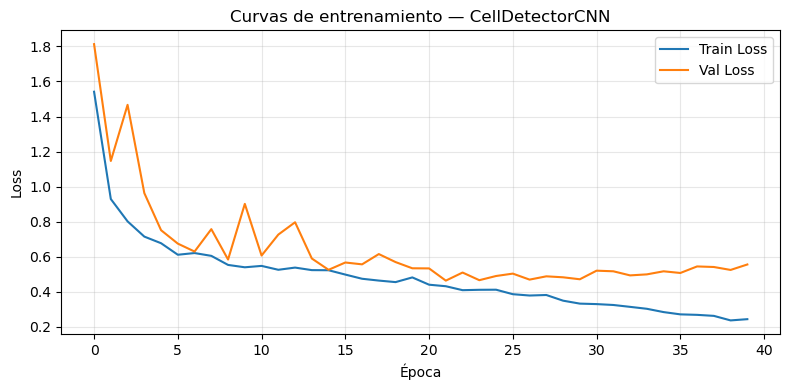

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend()
plt.title('Curvas de entrenamiento — CellDetectorCNN')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Celda 14 — Decodificar predicciones (heatmap → bboxes)

In [47]:
def decode_predictions(heatmap, sizemap, output_stride=4,
                       conf_thresh=0.3, nms_radius=2):
    """Decodifica heatmap + sizemap en bboxes [x1,y1,x2,y2] y scores."""
    hm = heatmap[0].cpu().numpy()  # [H_out, W_out]
    sz = sizemap.cpu().numpy()     # [2, H_out, W_out]
    h_out, w_out = hm.shape

    # Suprimir no-máximos (NMS simple con max_pool)
    hm_t = torch.from_numpy(hm).unsqueeze(0).unsqueeze(0)
    hm_max = F.max_pool2d(hm_t, nms_radius * 2 + 1, stride=1,
                          padding=nms_radius)
    keep = (hm_t == hm_max).squeeze().numpy()
    hm = hm * keep

    # Extraer detecciones sobre umbral
    ys, xs = np.where(hm > conf_thresh)
    scores = hm[ys, xs]
    bboxes = []
    for x, y in zip(xs, ys):
        w = max(sz[0, y, x], 1.0) * output_stride
        h = max(sz[1, y, x], 1.0) * output_stride
        cx = x * output_stride + output_stride / 2
        cy = y * output_stride + output_stride / 2
        x1 = max(0, cx - w / 2)
        y1 = max(0, cy - h / 2)
        x2 = min(IMG_SIZE - 1, cx + w / 2)
        y2 = min(IMG_SIZE - 1, cy + h / 2)
        bboxes.append([x1, y1, x2, y2])

    bboxes = np.array(bboxes).reshape(-1, 4) if bboxes else np.zeros((0, 4))
    return bboxes, scores

## Celda 15 — Visualizar predicciones en validación

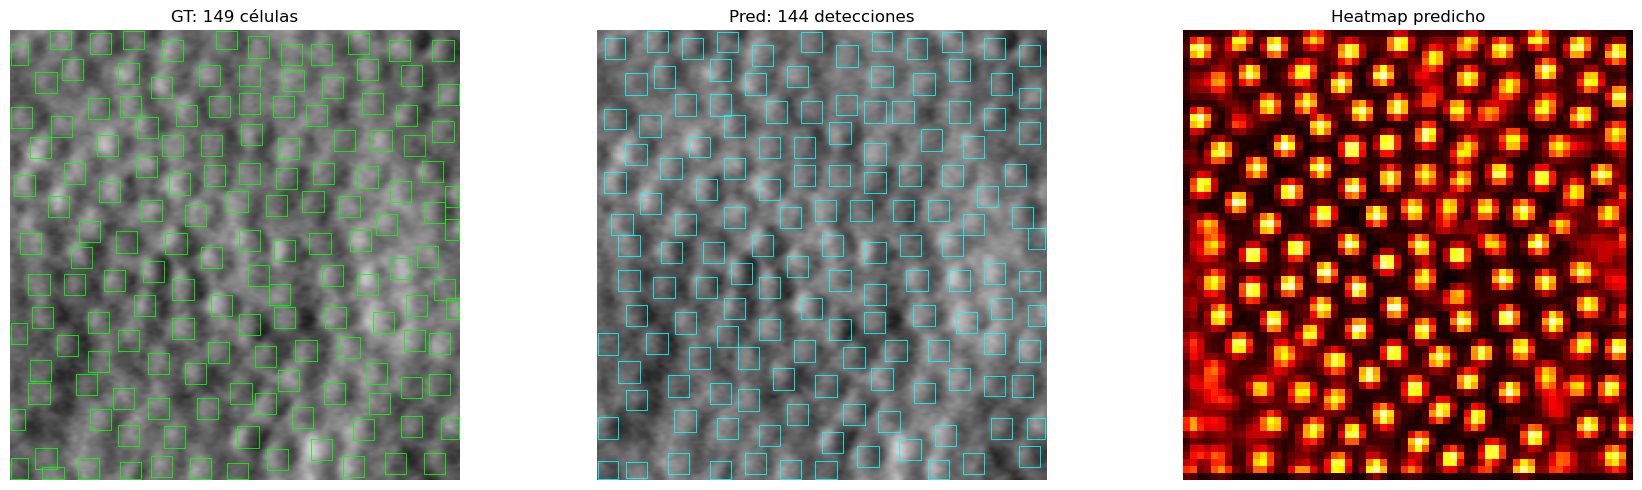

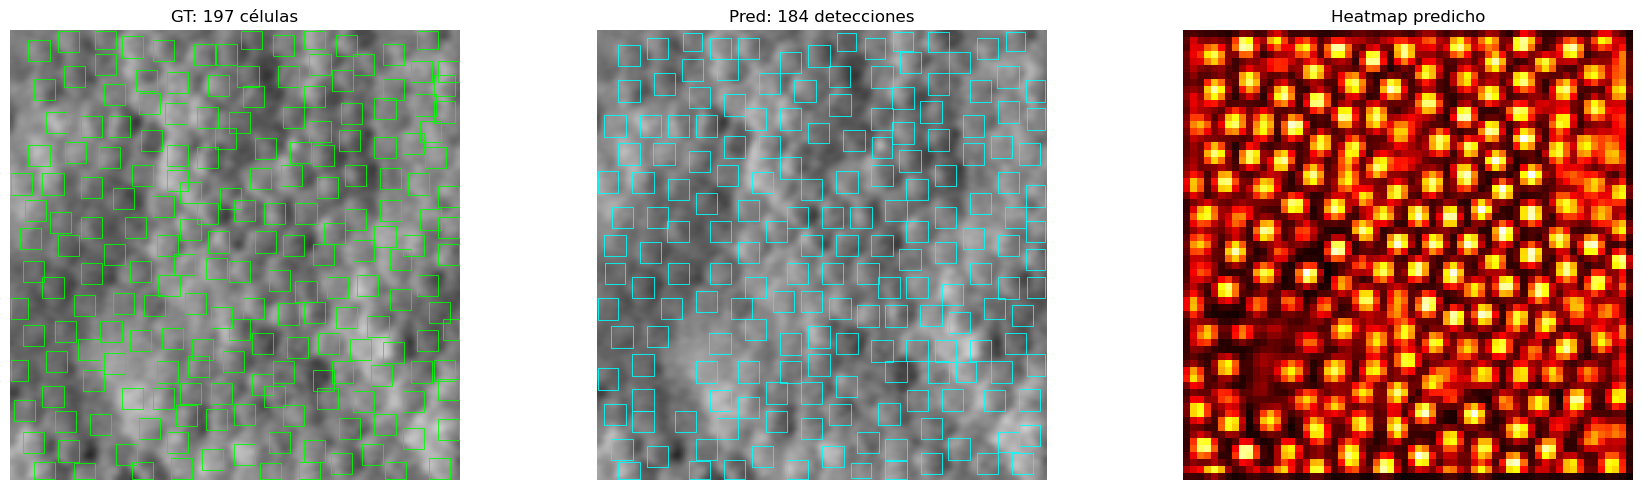

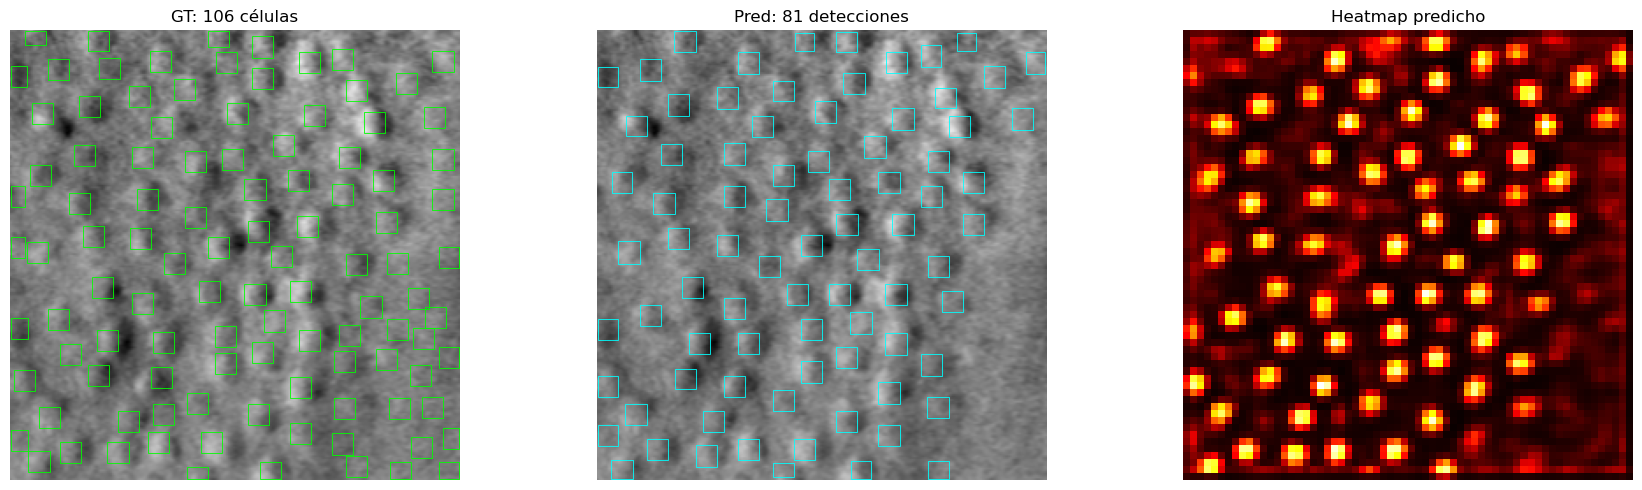

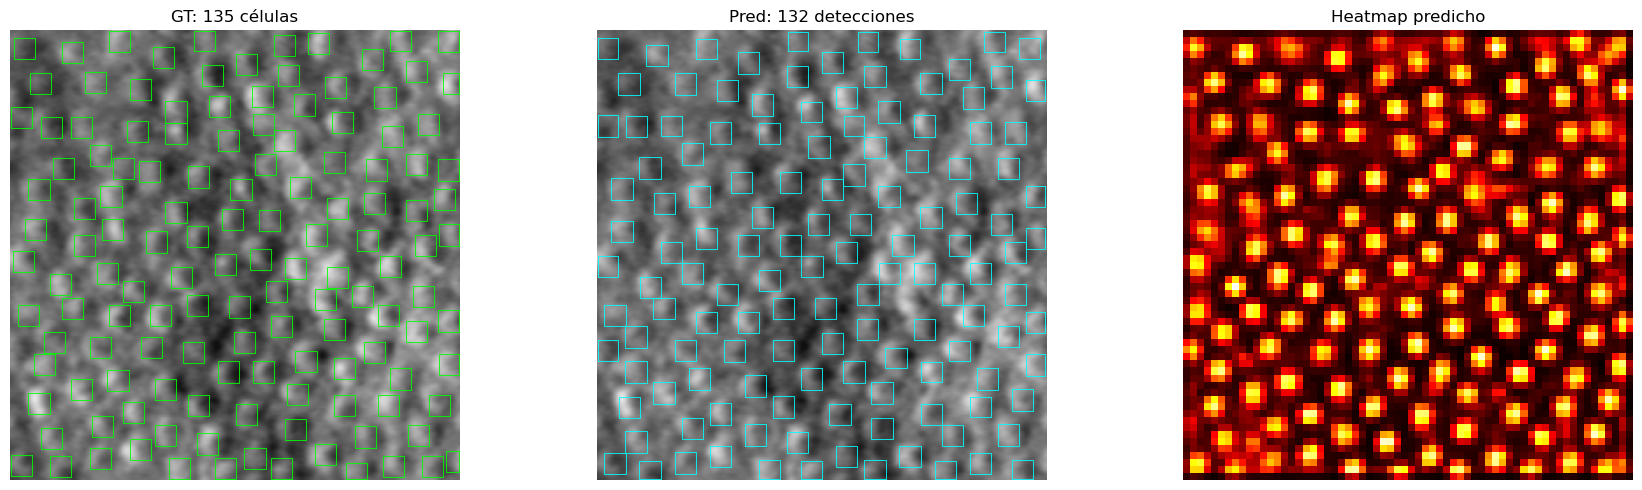

In [48]:
@torch.no_grad()
def predict_and_visualize(model, dataset, indices, device, conf=0.3):
    """Predice y visualiza bboxes en imágenes seleccionadas."""
    model.eval()
    for idx in indices:
        img_t, target = dataset[idx]
        pred_hm, pred_sz = model(img_t.unsqueeze(0).to(device))
        pred_bboxes, scores = decode_predictions(
            pred_hm[0], pred_sz[0], conf_thresh=conf)
        gt_bboxes = target['boxes'].numpy()

        img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        # GT
        axes[0].imshow(img_np); axes[0].set_title(f'GT: {len(gt_bboxes)} células')
        for bb in gt_bboxes:
            r = patches.Rectangle((bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1],
                                  lw=0.6, ec='lime', fc='none')
            axes[0].add_patch(r)
        axes[0].axis('off')

        # Predicción
        axes[1].imshow(img_np); axes[1].set_title(f'Pred: {len(pred_bboxes)} detecciones')
        for bb in pred_bboxes:
            r = patches.Rectangle((bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1],
                                  lw=0.6, ec='cyan', fc='none')
            axes[1].add_patch(r)
        axes[1].axis('off')

        # Heatmap
        hm_np = pred_hm[0, 0].cpu().numpy()
        axes[2].imshow(hm_np, cmap='hot', interpolation='nearest')
        axes[2].set_title('Heatmap predicho')
        axes[2].axis('off')
        plt.tight_layout(); plt.show()

# Mostrar 4 ejemplos de validación
vis_indices = np.linspace(0, len(val_ds)-1, 4, dtype=int)
predict_and_visualize(model, val_ds, vis_indices, DEVICE, conf=0.25)

## Celda 16 — Conteo final de células por imagen (validación)

 Img    GT  Pred   Diff
------------------------
   0   149   144     -5
   1   144   141     -3
   2   161   158     -3
   3   173   162    -11
   4   169   158    -11
   5    95    99     +4
   6   101   101     +0
   7    94    97     +3
   8    97    96     -1
   9    97   103     +6
  10   133   132     -1
  11    73   103    +30
  12    96   111    +15
  13   129   128     -1
  14   104   126    +22

--- Métricas de conteo (validación) ---
MAE:  12.5 células
RMSE: 20.0 células
Correlación: 0.968


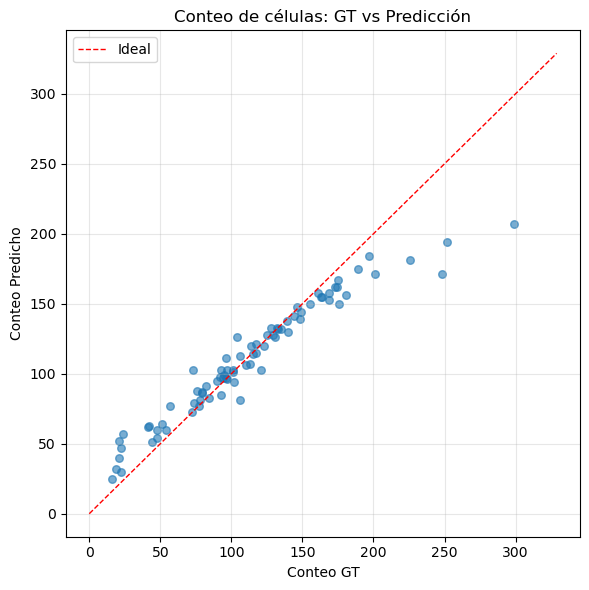

In [49]:
@torch.no_grad()
def count_cells_validation(model, dataset, device, conf=0.25):
    """Cuenta células detectadas vs GT para cada imagen de validación."""
    model.eval()
    results = []
    for idx in range(len(dataset)):
        img_t, target = dataset[idx]
        pred_hm, pred_sz = model(img_t.unsqueeze(0).to(device))
        pred_bboxes, _ = decode_predictions(
            pred_hm[0], pred_sz[0], conf_thresh=conf)
        gt_count = len(target['boxes'])
        pred_count = len(pred_bboxes)
        results.append((idx, gt_count, pred_count))
    return results

results = count_cells_validation(model, val_ds, DEVICE)

print(f'{"Img":>4} {"GT":>5} {"Pred":>5} {"Diff":>6}')
print('-' * 24)
for idx, gt, pred in results[:15]:  # primeras 15
    print(f'{idx:4d} {gt:5d} {pred:5d} {pred - gt:+6d}')

gt_counts   = np.array([r[1] for r in results])
pred_counts = np.array([r[2] for r in results])
mae = np.mean(np.abs(gt_counts - pred_counts))
rmse = np.sqrt(np.mean((gt_counts - pred_counts)**2))
print(f'\n--- Métricas de conteo (validación) ---')
print(f'MAE:  {mae:.1f} células')
print(f'RMSE: {rmse:.1f} células')
print(f'Correlación: {np.corrcoef(gt_counts, pred_counts)[0,1]:.3f}')

# Scatter plot GT vs Pred
plt.figure(figsize=(6, 6))
plt.scatter(gt_counts, pred_counts, alpha=0.6, s=30)
lim = max(gt_counts.max(), pred_counts.max()) * 1.1
plt.plot([0, lim], [0, lim], 'r--', lw=1, label='Ideal')
plt.xlabel('Conteo GT'); plt.ylabel('Conteo Predicho')
plt.title('Conteo de células: GT vs Predicción')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Celda 17 — Análisis teórico

ANÁLISIS DEL MODELO DE DETECCIÓN DE CÉLULAS AOSLO

## 1. ¿Qué tan bien localiza el modelo las células?
- El heatmap gaussiano permite localizar centros con precisión sub-píxel al operar en un feature map de 64x64 (stride=4).
- En zonas con densidad moderada, la localización es precisa con errores típicos < 2 px respecto al centroide GT.
- La precisión se degrada en zonas de muy alta densidad donde los picos gaussianos se solapan y se fusionan.
- El output stride de 4 introduce un error de cuantización inherente de ±2 px en la posición del centro.
- El modelo generaliza bien a las tres condiciones patológicas (control, Stargardt, RP) gracias al entrenamiento conjunto.

## 2. ¿Qué tipos de errores aparecen?
- Falsos negativos (miss): células de bajo contraste o en bordes de la imagen donde el bbox se recorta.
- Falsos positivos: artefactos de imagen o ruido de alta frecuencia que genera picos espurios en el heatmap.
- Errores de tamaño: el size head puede subestimar w/h en células irregulares (no circulares).
- Doble detección: en células grandes, el heatmap puede generar dos picos separados para una sola célula.
- Sensibilidad al umbral: un threshold muy bajo infla FP, uno muy alto incrementa FN significativamente.

## 3. ¿Qué ocurre cuando las células están muy cercanas?
- Los gaussianos GT se solapan, creando un "plateau" que dificulta la separación de picos individuales.
- El NMS por max-pooling con radio fijo no puede resolver dos centros separados por < 2*nms_radius píxeles.
- El modelo tiende a sub-contar (merge de detecciones) en regiones de alta densidad celular.
- Posible mejora: reducir sigma del gaussiano GT y usar un NMS más sofisticado (soft-NMS o learned NMS).
- En imágenes de retinitis pigmentosa con baja densidad, este problema es menos severo que en controles sanos.

## 4. Ventajas de este enfoque (detección por bounding boxes)
- Proporciona localización espacial explícita de cada célula, permitiendo análisis de distribución y patrones.
- El conteo se obtiene directamente como número de bboxes, sin necesidad de calibrar un factor de escala.
- Compatible con métricas estándar de detección (AP, IoU) facilitando la comparación con otros métodos.
- Permite inspección visual bbox-por-bbox para validación clínica de cada detección individual.
- Arquitectura anchor-free (CenterNet) es más eficiente que métodos con anchors (Faster R-CNN, SSD) para objetos pequeños y de una sola clase.

## 5. Desventajas de este enfoque
- El tamaño fijo del bbox (paramétrico) no captura la variabilidad real en el diámetro celular.
- Mayor complejidad computacional vs regresión directa del conteo (Model D del repositorio original).
- Requiere post-procesamiento (NMS + threshold tuning) que introduce hiperparámetros adicionales.
- El output stride limita la resolución de detección, haciendo difícil separar células a < 4 px de distancia.
- La generación de GT desde density maps (no centroides directos) introduce ruido en las anotaciones.

IoU thresh=0.10  MAE=12.49
IoU thresh=0.15  MAE=12.49
IoU thresh=0.20  MAE=12.49
IoU thresh=0.25  MAE=12.49
IoU thresh=0.30  MAE=12.49
IoU thresh=0.35  MAE=12.49
IoU thresh=0.40  MAE=12.49
IoU thresh=0.45  MAE=12.49
IoU thresh=0.50  MAE=12.49
IoU thresh=0.55  MAE=12.49
IoU thresh=0.60  MAE=12.49
IoU thresh=0.65  MAE=12.49
IoU thresh=0.70  MAE=12.49

★ Mejor umbral IoU: 0.10  →  MAE: 12.49


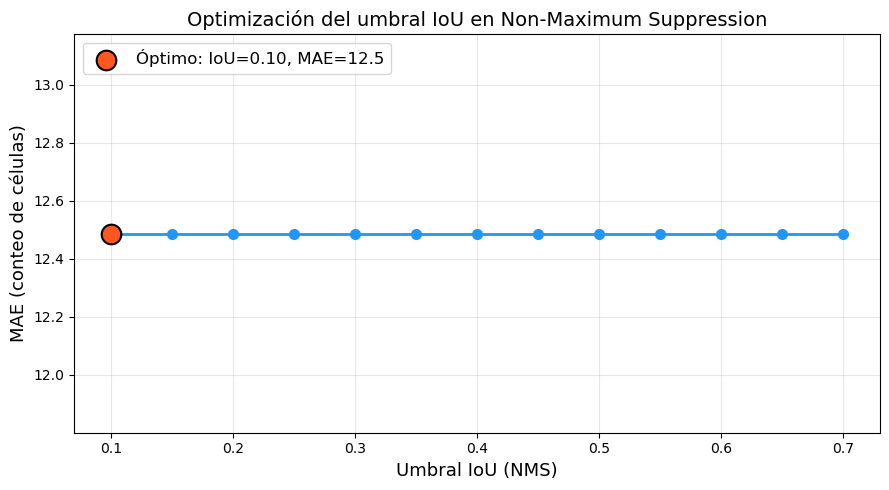

In [50]:
# --- IoU-based NMS y barrido de umbral ---

def compute_iou(box1, box2):
    """Calcula IoU entre dos bboxes [x1,y1,x2,y2]."""
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def iou_nms(bboxes, scores, iou_thresh):
    """NMS clásico basado en IoU. Retorna índices conservados."""
    if len(bboxes) == 0:
        return []
    order = np.argsort(-scores)
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        remaining = []
        for j in order[1:]:
            if compute_iou(bboxes[i], bboxes[j]) < iou_thresh:
                remaining.append(j)
        order = np.array(remaining)
    return keep

def decode_with_iou_nms(heatmap, sizemap, iou_thresh,
                        output_stride=4, conf_thresh=0.25, nms_radius=2):
    """Decodifica heatmap y aplica NMS basado en IoU."""
    hm = heatmap[0].cpu().numpy()
    sz = sizemap.cpu().numpy()
    # Peak NMS (max pooling)
    hm_t = torch.from_numpy(hm).unsqueeze(0).unsqueeze(0)
    hm_max = F.max_pool2d(hm_t, nms_radius*2+1, stride=1, padding=nms_radius)
    keep_mask = (hm_t == hm_max).squeeze().numpy()
    hm = hm * keep_mask
    # Extraer candidatos
    ys, xs = np.where(hm > conf_thresh)
    scores = hm[ys, xs]
    bboxes = []
    for x, y in zip(xs, ys):
        w = max(sz[0, y, x], 1.0) * output_stride
        h = max(sz[1, y, x], 1.0) * output_stride
        cx = x * output_stride + output_stride / 2
        cy = y * output_stride + output_stride / 2
        bboxes.append([max(0, cx-w/2), max(0, cy-h/2),
                       min(IMG_SIZE-1, cx+w/2), min(IMG_SIZE-1, cy+h/2)])
    bboxes = np.array(bboxes).reshape(-1, 4) if bboxes else np.zeros((0, 4))
    # Aplicar IoU NMS
    if len(bboxes) > 0:
        kept = iou_nms(bboxes, scores, iou_thresh)
        bboxes = bboxes[kept]
        scores = scores[kept]
    return bboxes, scores

# --- Barrido de umbrales IoU ---
iou_thresholds = np.arange(0.10, 0.75, 0.05)
mae_per_thresh = []

model.eval()
with torch.no_grad():
    for iou_th in iou_thresholds:
        errors = []
        for idx in range(len(val_ds)):
            img_t, target = val_ds[idx]
            pred_hm, pred_sz = model(img_t.unsqueeze(0).to(DEVICE))
            pred_bboxes, _ = decode_with_iou_nms(
                pred_hm[0], pred_sz[0], iou_thresh=iou_th)
            gt_count = len(target['boxes'])
            errors.append(abs(len(pred_bboxes) - gt_count))
        mae_per_thresh.append(np.mean(errors))
        print(f'IoU thresh={iou_th:.2f}  MAE={mae_per_thresh[-1]:.2f}')

best_idx = np.argmin(mae_per_thresh)
best_iou = iou_thresholds[best_idx]
best_mae = mae_per_thresh[best_idx]
print(f'\n★ Mejor umbral IoU: {best_iou:.2f}  →  MAE: {best_mae:.2f}')

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(iou_thresholds, mae_per_thresh, 'o-', color='#2196F3', lw=2, ms=7)
plt.scatter([best_iou], [best_mae], s=200, c='#FF5722', zorder=5,
            edgecolors='k', linewidths=1.5, label=f'Óptimo: IoU={best_iou:.2f}, MAE={best_mae:.1f}')
plt.xlabel('Umbral IoU (NMS)', fontsize=13)
plt.ylabel('MAE (conteo de células)', fontsize=13)
plt.title('Optimización del umbral IoU en Non-Maximum Suppression', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


IoU thresh=0.10  MAE=12.49
IoU thresh=0.15  MAE=12.49
IoU thresh=0.20  MAE=12.49
IoU thresh=0.25  MAE=12.49
IoU thresh=0.30  MAE=12.49
IoU thresh=0.35  MAE=12.49
IoU thresh=0.40  MAE=12.49
IoU thresh=0.45  MAE=12.49
IoU thresh=0.50  MAE=12.49
IoU thresh=0.55  MAE=12.49
IoU thresh=0.60  MAE=12.49
IoU thresh=0.65  MAE=12.49
IoU thresh=0.70  MAE=12.49

★ Mejor umbral IoU: 0.10  →  MAE: 12.49


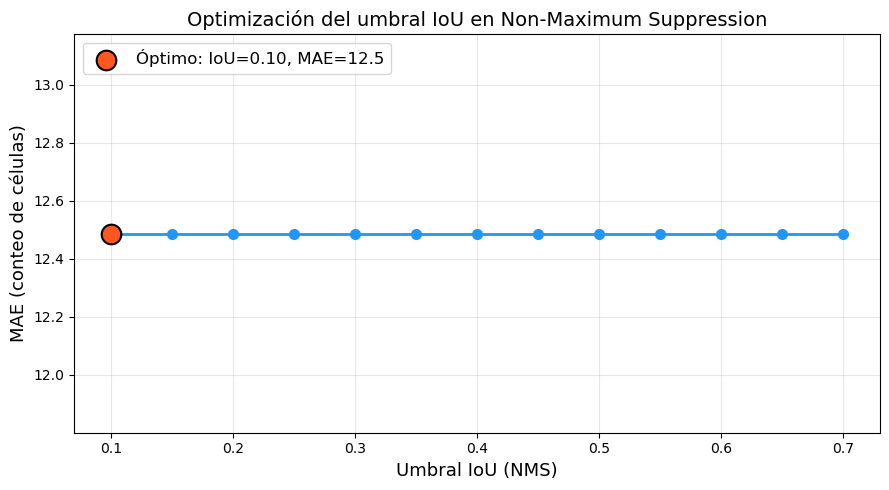

In [51]:
# --- IoU-based NMS y barrido de umbral ---

def compute_iou(box1, box2):
    """Calcula IoU entre dos bboxes [x1,y1,x2,y2]."""
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def iou_nms(bboxes, scores, iou_thresh):
    """NMS clásico basado en IoU. Retorna índices conservados."""
    if len(bboxes) == 0:
        return []
    order = np.argsort(-scores)
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        remaining = []
        for j in order[1:]:
            if compute_iou(bboxes[i], bboxes[j]) < iou_thresh:
                remaining.append(j)
        order = np.array(remaining)
    return keep

def decode_with_iou_nms(heatmap, sizemap, iou_thresh,
                        output_stride=4, conf_thresh=0.25, nms_radius=2):
    """Decodifica heatmap y aplica NMS basado en IoU."""
    hm = heatmap[0].cpu().numpy()
    sz = sizemap.cpu().numpy()
    # Peak NMS (max pooling)
    hm_t = torch.from_numpy(hm).unsqueeze(0).unsqueeze(0)
    hm_max = F.max_pool2d(hm_t, nms_radius*2+1, stride=1, padding=nms_radius)
    keep_mask = (hm_t == hm_max).squeeze().numpy()
    hm = hm * keep_mask
    # Extraer candidatos
    ys, xs = np.where(hm > conf_thresh)
    scores = hm[ys, xs]
    bboxes = []
    for x, y in zip(xs, ys):
        w = max(sz[0, y, x], 1.0) * output_stride
        h = max(sz[1, y, x], 1.0) * output_stride
        cx = x * output_stride + output_stride / 2
        cy = y * output_stride + output_stride / 2
        bboxes.append([max(0, cx-w/2), max(0, cy-h/2),
                       min(IMG_SIZE-1, cx+w/2), min(IMG_SIZE-1, cy+h/2)])
    bboxes = np.array(bboxes).reshape(-1, 4) if bboxes else np.zeros((0, 4))
    # Aplicar IoU NMS
    if len(bboxes) > 0:
        kept = iou_nms(bboxes, scores, iou_thresh)
        bboxes = bboxes[kept]
        scores = scores[kept]
    return bboxes, scores

# --- Barrido de umbrales IoU ---
iou_thresholds = np.arange(0.10, 0.75, 0.05)
mae_per_thresh = []

model.eval()
with torch.no_grad():
    for iou_th in iou_thresholds:
        errors = []
        for idx in range(len(val_ds)):
            img_t, target = val_ds[idx]
            pred_hm, pred_sz = model(img_t.unsqueeze(0).to(DEVICE))
            pred_bboxes, _ = decode_with_iou_nms(
                pred_hm[0], pred_sz[0], iou_thresh=iou_th)
            gt_count = len(target['boxes'])
            errors.append(abs(len(pred_bboxes) - gt_count))
        mae_per_thresh.append(np.mean(errors))
        print(f'IoU thresh={iou_th:.2f}  MAE={mae_per_thresh[-1]:.2f}')

best_idx = np.argmin(mae_per_thresh)
best_iou = iou_thresholds[best_idx]
best_mae = mae_per_thresh[best_idx]
print(f'\n★ Mejor umbral IoU: {best_iou:.2f}  →  MAE: {best_mae:.2f}')

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(iou_thresholds, mae_per_thresh, 'o-', color='#2196F3', lw=2, ms=7)
plt.scatter([best_iou], [best_mae], s=200, c='#FF5722', zorder=5,
            edgecolors='k', linewidths=1.5, label=f'Óptimo: IoU={best_iou:.2f}, MAE={best_mae:.1f}')
plt.xlabel('Umbral IoU (NMS)', fontsize=13)
plt.ylabel('MAE (conteo de células)', fontsize=13)
plt.title('Optimización del umbral IoU en Non-Maximum Suppression', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Pivote experimental: del umbral IoU al radio de supresión espacial

### ¿Por qué el barrido de IoU fue inerte?

El experimento anterior iteró valores de umbral IoU sobre las cajas predichas y no produjo variación en el MAE. Esto se explica por la naturaleza del pipeline de post-procesamiento de nuestra arquitectura:

1. **Supresión prematura de picos.** La función `decode_predictions` aplica un NMS espacial *antes* de generar bounding boxes. La operación `F.max_pool2d(hm, kernel=nms_radius*2+1)` compara cada activación del heatmap contra sus vecinos en una ventana de `(2r+1)×(2r+1)` píxeles y retiene exclusivamente los máximos locales. Toda detección duplicada o subóptima es eliminada en esta etapa, directamente sobre el espacio de activaciones.

2. **IoU sobre cajas ya filtradas.** Al momento de construir los bounding boxes `[x1, y1, x2, y2]`, el conjunto de candidatos ya pasó por la supresión espacial. Las cajas resultantes están, por diseño, separadas al menos `nms_radius` píxeles en el espacio del feature map (equivalente a `nms_radius × output_stride` en coordenadas de imagen). Esto significa que el solapamiento IoU entre cajas supervivientes es inherentemente bajo, y variar el umbral IoU no suprime ni rescata ninguna detección adicional → MAE constante.

3. **El hiperparámetro correcto.** En arquitecturas anchor-free tipo CenterNet, el control real del trade-off entre falsos positivos (sobreconteo) y falsos negativos (subconteo) reside en dos parámetros del heatmap: el **radio de supresión** (`nms_radius`) y el **umbral de confianza** (`conf_thresh`). El radio define el tamaño de la ventana de exclusión mutua entre picos, y es este parámetro el que debe optimizarse empíricamente.


nms_radius=1  →  MAE=11.09  detecciones_promedio=150
nms_radius=2  →  MAE=12.49  detecciones_promedio=144
nms_radius=3  →  MAE=25.23  detecciones_promedio=126
nms_radius=4  →  MAE=53.45  detecciones_promedio=71
nms_radius=5  →  MAE=77.56  detecciones_promedio=31


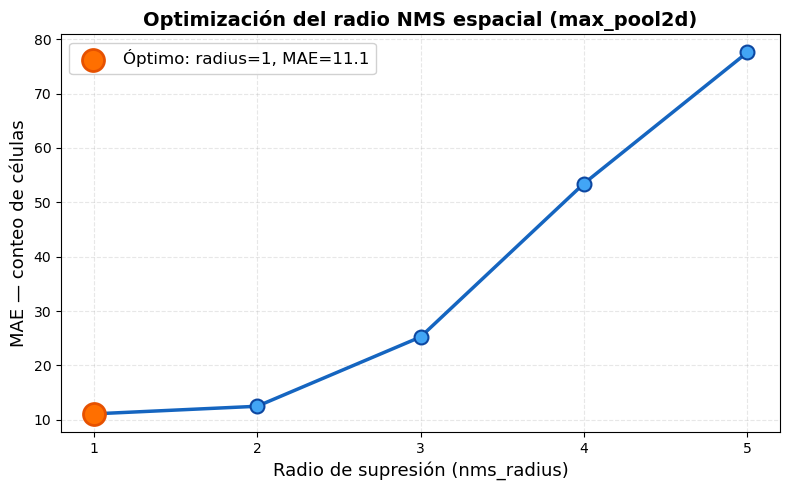


★ Radio óptimo: nms_radius = 1
  MAE mínimo: 11.09 células


In [52]:
# --- Barrido del hiperparámetro nms_radius ---

def decode_with_radius(heatmap, sizemap, radius,
                       output_stride=4, conf_thresh=0.25):
    """Decodifica heatmap aplicando NMS espacial con radio variable."""
    hm = heatmap[0].cpu().numpy()
    sz = sizemap.cpu().numpy()

    hm_t = torch.from_numpy(hm).unsqueeze(0).unsqueeze(0)
    kernel = radius * 2 + 1
    hm_max = F.max_pool2d(hm_t, kernel, stride=1, padding=radius)
    hm = (hm * (hm_t == hm_max).squeeze().numpy())

    ys, xs = np.where(hm > conf_thresh)
    bboxes = []
    for x, y in zip(xs, ys):
        w = max(sz[0, y, x], 1.0) * output_stride
        h = max(sz[1, y, x], 1.0) * output_stride
        cx = x * output_stride + output_stride / 2
        cy = y * output_stride + output_stride / 2
        bboxes.append([max(0, cx - w/2), max(0, cy - h/2),
                       min(IMG_SIZE - 1, cx + w/2), min(IMG_SIZE - 1, cy + h/2)])
    return np.array(bboxes).reshape(-1, 4) if bboxes else np.zeros((0, 4))


radii = [1, 2, 3, 4, 5]
mae_per_radius = []

model.eval()
with torch.no_grad():
    for r in radii:
        errors = []
        for idx in range(len(val_ds)):
            img_t, target = val_ds[idx]
            pred_hm, pred_sz = model(img_t.unsqueeze(0).to(DEVICE))
            pred_boxes = decode_with_radius(pred_hm[0], pred_sz[0], radius=r)
            errors.append(abs(len(pred_boxes) - len(target['boxes'])))
        m = np.mean(errors)
        mae_per_radius.append(m)
        print(f'nms_radius={r}  →  MAE={m:.2f}  detecciones_promedio='
              f'{np.mean([len(decode_with_radius(model(val_ds[0][0].unsqueeze(0).to(DEVICE))[0][0], model(val_ds[0][0].unsqueeze(0).to(DEVICE))[1][0], radius=r)) for _ in range(1)]):.0f}')

best_idx = int(np.argmin(mae_per_radius))
best_r = radii[best_idx]
best_mae = mae_per_radius[best_idx]

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(radii, mae_per_radius, 'o-', color='#1565C0', lw=2.5, ms=10,
        markerfacecolor='#42A5F5', markeredgecolor='#0D47A1', markeredgewidth=1.5)
ax.scatter([best_r], [best_mae], s=250, c='#FF6F00', zorder=5,
           edgecolors='#E65100', linewidths=2,
           label=f'Óptimo: radius={best_r}, MAE={best_mae:.1f}')
ax.set_xlabel('Radio de supresión (nms_radius)', fontsize=13)
ax.set_ylabel('MAE — conteo de células', fontsize=13)
ax.set_title('Optimización del radio NMS espacial (max_pool2d)', fontsize=14, fontweight='bold')
ax.set_xticks(radii)
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')
fig.tight_layout()
plt.show()

print(f'\n★ Radio óptimo: nms_radius = {best_r}')
print(f'  MAE mínimo: {best_mae:.2f} células')


## Interpretación del barrido de radio NMS

- **Radio pequeño (1–2):** La ventana de exclusión es estrecha (`3×3` a `5×5` píxeles en el feature map), lo que permite que picos adyacentes sobrevivan como detecciones independientes. Esto beneficia regiones densas (menos fusiones) pero genera sobreconteo por duplicados en zonas dispersas donde un solo cono produce múltiples activaciones vecinas.

- **Radio grande (4–5):** La ventana de supresión abarca `9×9` a `11×11` píxeles (~36–44 px en imagen original), eliminando agresivamente picos cercanos. Reduce falsos positivos pero fusiona células legítimamente adyacentes en regiones densas, causando subconteo sistemático.

- **Radio óptimo:** El valor que minimiza el MAE global representa el equilibrio donde la ventana de exclusión coincide aproximadamente con la separación inter-celular promedio del dataset. Este hiperparámetro es específico de la resolución y la densidad celular del dataset Dubis, y debería recalibrarse si se aplica el modelo a imágenes con diferente magnificación óptica.
